## Customer Churn Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("darkgrid")

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from scipy.stats import pearsonr

encoder = OrdinalEncoder()

### Data Preparation on EDA

In [ ]:
def data_preparation(file_path: str, is_excel: bool = False, sheet_name: bool = None):
    df = (
        pd.read_csv(file_path)
        if not is_excel
        else pd.read_excel(file_path, sheet_name=sheet_name)
    )

    df.drop(["CustomerID"], axis=1, inplace=True)
    df.Tenure = df.Tenure.apply(lambda x: (x // 12) + 1)

    df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
    df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
        {"Cash on Delivery": "COD", "CC": "Credit Card"}
    )
    df.PreferedOrderCat = df.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})

    # To handle correlation
    df["Tenure_Cashback"] = df.Tenure * df.CashbackAmount
    df.drop(["Tenure", "CashbackAmount"], axis=1, inplace=True)

    df[
        [
            "PreferredLoginDevice",
            "PreferredPaymentMode",
            "Gender",
            "PreferedOrderCat",
            "MaritalStatus",
        ]
    ] = encoder.fit_transform(
        df[
            [
                "PreferredLoginDevice",
                "PreferredPaymentMode",
                "Gender",
                "PreferedOrderCat",
                "MaritalStatus",
            ]
        ]
    )

    return df

In [70]:
df = data_preparation("E Commerce Dataset.xlsx", is_excel=True, sheet_name="E Comm")

In [71]:
df.head()

,Churn,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,Tenure_Cashback
0,1,1.0,3,6.0,2.0,0.0,3.0,3,2.0,2,2.0,9,1,11.0,1.0,1.0,5.0,159.93
1,1,1.0,1,8.0,4.0,1.0,3.0,4,3.0,3,2.0,7,1,15.0,0.0,1.0,0.0,NaN
2,1,1.0,1,30.0,2.0,1.0,2.0,4,3.0,3,2.0,6,1,14.0,0.0,1.0,3.0,NaN
3,1,1.0,3,15.0,2.0,1.0,2.0,4,2.0,5,2.0,8,0,23.0,0.0,1.0,3.0,134.07
4,1,1.0,1,12.0,1.0,1.0,NaN,3,3.0,5,2.0,3,0,11.0,1.0,1.0,3.0,129.60


In [72]:
df.isnull().sum()

Churn                            0
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
Tenure_Cashback                264
dtype: int64

### Moddel Building

In [65]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier

In [73]:
X = df.drop(["Churn"], axis=1).columns.tolist()
y = "Churn"

train, test = train_test_split(df, test_size=0.25, random_state=0, stratify=df.Churn)
x_train = train[X]
x_test = test[X]
y_train = train[y]
y_test = test[y]

In [34]:
def churn_prediction(
    algo, x_train, x_test, y_train, y_test, columns, cf="coefficients"
):
    algo.fit(x_train, y_train)
    predictions = algo.predict(x_test)
    probabilities = algo.predict_proba(x_test)[:, 1]

    train_predictions = algo.predict(x_train)
    train_probabilities = algo.predict_proba(x_train)[:, 1]

    # Coefficients
    if cf == "coefficients":
        coefficients = pd.DataFrame(algo.named_steps["model"].coef_.ravel())
    elif cf == "features":
        coefficients = pd.DataFrame(algo.named_steps["model"].feature_importances_)

    column_df = pd.DataFrame(columns)
    coef_summary = pd.merge(
        coefficients, column_df, left_index=True, right_index=True, how="left"
    )
    coef_summary.columns = ["coefficients", "features"]
    coef_summary = coef_summary.sort_values(by="coefficients", ascending=False)

    print(algo)
    print(
        "Test Classification Report:\n",
        classification_report(y_test, predictions),
    )
    print(
        "Test Accuracy Score:",
        accuracy_score(y_test, predictions),
    )

    # if on_train_set:
    print("-" * 50)
    print(
        "Train Classification Report:\n",
        classification_report(y_train, train_predictions),
    )
    print(
        "Train Accuracy Score:",
        accuracy_score(y_train, train_predictions),
    )

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, predictions)
    train_conf_matrix = confusion_matrix(y_train, train_predictions)

    plt.figure(figsize=(10, 14))
    plt.subplot(321)  # 221
    sns.heatmap(conf_matrix, fmt="d", annot=True, cmap="Blues")
    plt.title("Test Confusion Matrix")
    plt.ylabel("True Values")
    plt.xlabel("Predicted Values")

    plt.subplot(322)
    sns.heatmap(train_conf_matrix, fmt="d", annot=True, cmap="Blues")
    plt.title("Train Confusion Matrix")
    plt.ylabel("True Values")
    plt.xlabel("Predicted Values")

    # ROC-AUC Score
    test_roc_auc = roc_auc_score(y_test, probabilities)
    train_roc_auc = roc_auc_score(y_train, train_probabilities)
    print("Area under curve(Test): ", test_roc_auc)
    print("Area under curve(Train): ", train_roc_auc)
    fpr, tpr, thresholds = roc_curve(y_test, probabilities)
    train_fpr, train_tpr, train_thresholds = roc_curve(y_train, train_probabilities)

    plt.subplot(323)  # 222
    plt.plot(fpr, tpr, color="orange", lw=1, label="AUC: %.3f" % test_roc_auc)
    plt.plot([0, 1], [0, 1], color="blue", lw=1, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (Test)")
    plt.legend(loc="lower right")

    plt.subplot(324)
    plt.plot(
        train_fpr, train_tpr, color="orange", lw=1, label="AUC: %.3f" % train_roc_auc
    )
    plt.plot([0, 1], [0, 1], color="blue", lw=1, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (Train)")
    plt.legend(loc="lower right")

    plt.subplot(313)  # 212
    sns.barplot(x=coef_summary["features"], y=coef_summary["coefficients"])
    plt.title("Feature Importances")
    plt.xticks(rotation="vertical")

    plt.show()

### Pipeline

In [19]:
from sklearn.pipeline import Pipeline


def piped(model):
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Hyperparameters Tuning

#### Grid 1: Selecting Class Weight & Estimators

In [ ]:
param_grid1 = {
    "model__max_features": ["sqrt", "log2", None],
    "model__n_estimators": [700, 900, 1100],
}

rf_model = RandomForestClassifier()
grid1 = GridSearchCV(
    estimator=piped(rf_model),
    param_grid=param_grid1,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    scoring="f1",
)
grid1.fit(x_train, y_train)

In [ ]:
grid1.best_estimator_

In [ ]:
dt = pd.DataFrame(grid1.cv_results_)
dt.param_model__max_features = dt.param_model__max_features.astype(str)
dt.param_model__n_estimators = dt.param_model__n_estimators.astype(str)

table = pd.pivot_table(dt, values="mean_test_score", index="param_model__n_estimators", columns="param_model__max_features")
sns.heatmap(table)

In [35]:
grid1.best_score_

np.float64(0.7795113819483961)

#### Grid2: Max Depth and Spilt

In [ ]:
param_grid2 = {
    "model__max_features": [None],
    "model__n_estimators": [1000, 1100],
    "model__criterion": ["entropy", "gini"],
    "model__max_depth": [9, 10, None],
}

rf_model = RandomForestClassifier()
grid2 = GridSearchCV(
    estimator=piped(rf_model),
    param_grid=param_grid2,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    scoring="f1",
)
grid2.fit(x_train, y_train)

In [ ]:
grid2.best_estimator_

In [ ]:
dt = pd.DataFrame(grid2.cv_results_)

table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__criterion",
)
sns.heatmap(table)

In [48]:
dt.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__criterion', 'param_model__max_depth',
       'param_model__max_features', 'param_model__n_estimators', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [ ]:
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__n_estimators",
)
sns.heatmap(table)

In [56]:
grid2.best_score_

np.float64(0.7841075245868158)

#### Grid 3: Minimum Samples Leaf and Split

In [ ]:
param_grid3 = {
    "model__max_features": [None],
    "model__n_estimators": [1000],
    "model__criterion": ["gini"],
    "model__max_depth": [10],
    "model__min_samples_leaf": [1, 3, 5, 7],
    "model__min_samples_split": [2, 4, 6, 8],
}
rf_model = RandomForestClassifier()
grid3 = GridSearchCV(
    estimator=piped(rf_model),
    param_grid=param_grid3,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    scoring="f1",
)
grid3.fit(x_train, y_train)

In [ ]:
grid3.best_estimator_

<Axes: xlabel='param_model__min_samples_split', ylabel='param_model__min_samples_leaf'>

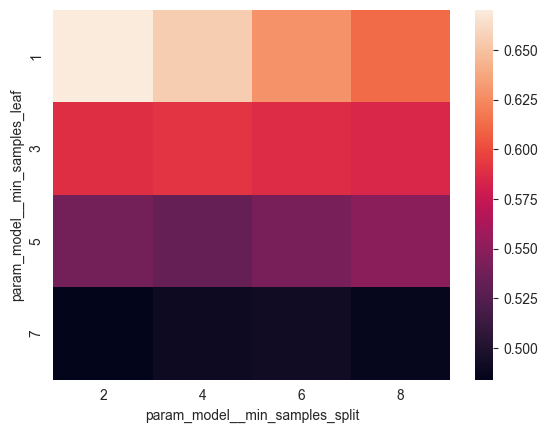

In [59]:
dt = pd.DataFrame(grid3.cv_results_)
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_model__min_samples_leaf",
    columns="param_model__min_samples_split",
)

sns.heatmap(table)

In [60]:
grid3.best_score_

np.float64(0.6702201347364675)

#### Grid 4: Selecting Class Weights

In [ ]:
param_grid4 = {
    "model__class_weight": [{0: 1, 1: 1}, {0: 1, 1: 2}, {0: 1, 1: 3}],
    "model__max_features": [None],
    "model__n_estimators": [1000],
    "model__criterion": ["gini"],
    "model__max_depth": [10],
    "model__min_samples_leaf": [1],
    "model__min_samples_split": [2],
}

rf_model = RandomForestClassifier()
grid4 = GridSearchCV(
    estimator=piped(rf_model),
    param_grid=param_grid4,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    scoring="f1",
)
grid4.fit(x_train, y_train)

In [ ]:
grid4.best_estimator_

<Axes: ylabel='param_model__class_weight'>

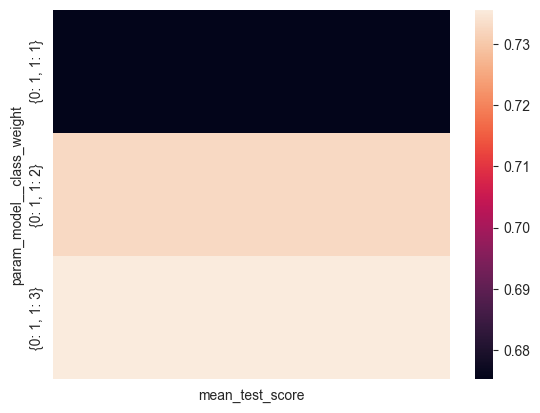

In [66]:
dt = pd.DataFrame(grid4.cv_results_)
dt.param_model__class_weight = dt.param_model__class_weight.astype(str)
table = pd.pivot_table(dt, values="mean_test_score", index="param_model__class_weight")

sns.heatmap(table)

In [67]:
grid4.best_score_

np.float64(0.7355980680044218)

#### Final Grid Search

In [ ]:
param_grid5 = {
    "model__class_weight": [{0: 1, 1: 2}, {0: 1, 1: 3}],
    "model__max_features": [None],
    "model__n_estimators": [1000],
    "model__criterion": ["gini"],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_leaf": [20, 30, 45],
    "model__min_samples_split": [2],
}

rf_model = RandomForestClassifier()
grid5 = GridSearchCV(
    estimator=piped(rf_model),
    param_grid=param_grid5,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    scoring="f1",
)
grid5.fit(x_train, y_train)

<Axes: xlabel='param_model__max_depth'>

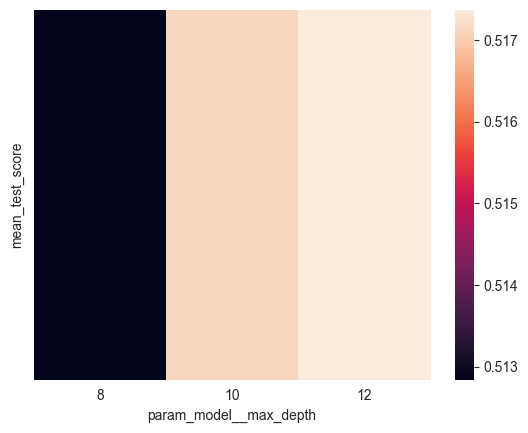

In [128]:
dt = pd.DataFrame(grid5.cv_results_)
dt.param_model__class_weight = dt.param_model__class_weight.astype(str)
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    # index="param_model__class_weight",
    columns="param_model__max_depth",
)

sns.heatmap(table)

<Axes: xlabel='param_model__min_samples_leaf', ylabel='param_model__max_depth'>

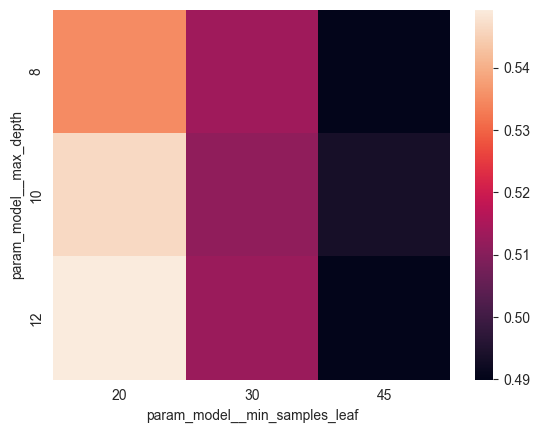

In [129]:
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__min_samples_leaf",
)

sns.heatmap(table)

In [130]:
grid5.best_score_

np.float64(0.5598193300708125)

In [131]:
grid5.best_params_

{'model__class_weight': {0: 1, 1: 3},
 'model__criterion': 'gini',
 'model__max_depth': 12,
 'model__max_features': None,
 'model__min_samples_leaf': 20,
 'model__min_samples_split': 2,
 'model__n_estimators': 1000}

### Final Model

In [74]:
model = RandomForestClassifier(
    bootstrap=True,
    ccp_alpha=0.0,
    class_weight={0: 1, 1: 3.4},
    criterion="entropy",
    max_depth=5,
    max_features="sqrt",
    max_leaf_nodes=None,
    max_samples=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=20,
    min_samples_split=30,
    min_weight_fraction_leaf=0,
    n_estimators=1000,
    n_jobs=None,
    oob_score=False,
    random_state=None,
    verbose=0,
    warm_start=False,
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 3.4},
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=20,
                                        min_samples_split=30,
                                        min_weight_fraction_leaf=0,
                                        n_estimators=1000))])
Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1171
           1       0.56      0.62      0.59       237

    accuracy                           0.85      1408
   macro avg       0.74      0.76      0.75      1408
weighted avg       0.86      0.85      0.86      1408

Test Accuracy Score: 0.8536931818181818
--------------------------------------------------
Train Classification Report:
               precision    recall  f1-

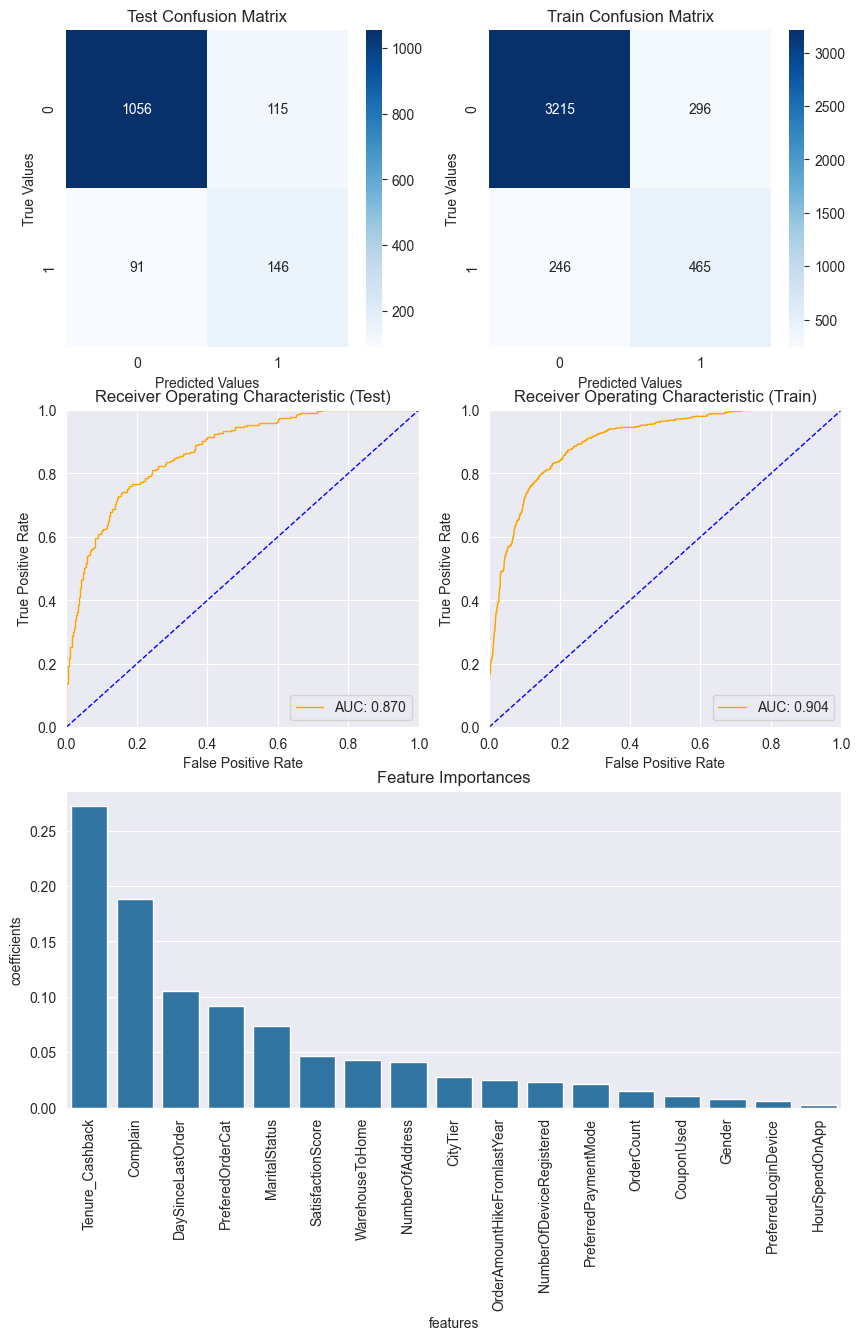

In [75]:
churn_prediction(piped(model), x_train, x_test, y_train, y_test, X, "features")

Checking with training data

In [76]:
train_scores = cross_val_score(piped(model), x_train, y_train, cv=cv, scoring="f1")
train_scores

array([0.64473684, 0.61428571, 0.58823529, 0.56849315, 0.52595156])

In [77]:
np.mean(train_scores)

np.float64(0.5883405116573964)